In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Generate 8 random numbers from 500 to 2000 for each setting
image_counts_A1 = np.sort(np.random.randint(500, 2000, 8))
image_counts_A2 = np.sort(np.random.randint(500, 2000, 8))
image_counts_A3 = np.sort(np.random.randint(500, 2000, 8))

# Generate 8 random numbers from 0.1 to 0.6 for each setting
foreground_ratios_A1 = np.sort(np.random.uniform(0.1, 0.6, 8))[::-1]
foreground_ratios_A2 = np.sort(np.random.uniform(0.1, 0.6, 8))[::-1]
foreground_ratios_A3 = np.sort(np.random.uniform(0.1, 0.6, 8))[::-1]

# Create the DataFrame
df = pd.DataFrame({
    'Category': ['Category' + str(i+1) for i in range(8)],
    'Image Count (A1)': image_counts_A1,
    'Image Count (A2)': image_counts_A2,
    'Image Count (A3)': image_counts_A3,
    'Foreground Ratio (A1)': foreground_ratios_A1,
    'Foreground Ratio (A2)': foreground_ratios_A2,
    'Foreground Ratio (A3)': foreground_ratios_A3,
})

print(df)



In [1]:
import os
print(os.getcwd())

c:\Users\ZT\OneDrive\Studying\Yiling\00Research\202401_experiment\code\draw


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Specify the path of your CSV file
file_path = 'data.csv'

# Read the CSV data
df = pd.read_csv(file_path)

# Print the DataFrame
print(df)
print(df.columns)

   类别   0.3   0.2   0.1  0.05  0.01  0.001     0      10.3      10.2  \
0  耕地   541  1053  2022  2899  4448   5393  5801  0.412315  0.330591   
1  森林  4521  4837  5332  5691  5920   5961  5963  0.780835  0.746151   
2  草地     8    48   261   866  3858   5781  5948  0.348421  0.252753   
3  灌木     0     0     0     1    42    808  3506  0.000000  0.000000   
4  湿地     0     0     0     5   104    940  2504  0.000000  0.000000   
5  水体   212   389   758  1215  2294   3419  3947  0.469035  0.365951   
6  建筑   964  1318  1911  2541  3884   5023  5630  0.524473  0.449350   
7  荒地   109   499  1662  2894  4594   5685  5922  0.355791  0.263581   

       10.1     10.05     10.01    10.001        10  
0  0.240619  0.189874  0.133171  0.110648  0.102893  
1  0.690372  0.651542  0.627570  0.623294  0.623085  
2  0.157068  0.095628  0.039730  0.028276  0.027498  
3  0.000000  0.000000  0.016520  0.003480  0.000989  
4  0.000000  0.069122  0.021035  0.004938  0.002038  
5  0.258206  0.188104  0.11

In [2]:
df.iloc[0, 1:8]
print(df.index)
print(df.columns)

RangeIndex(start=0, stop=8, step=1)
Index(['类别', '0.3', '0.2', '0.1', '0.05', '0.01', '0.001', '0', '10.3', '10.2',
       '10.1', '10.05', '10.01', '10.001', '10'],
      dtype='object')


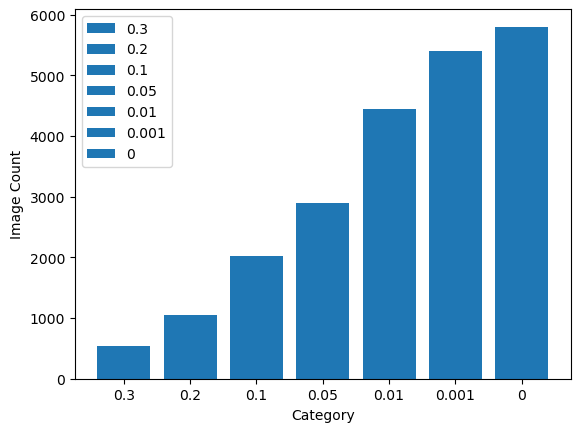

In [6]:
categories = df['类别']
settings = ['0.3', '0.2', '0.1', '0.05', '0.01', '0.001', '0']
image_counts = ['0.3', '0.2', '0.1', '0.05', '0.01', '0.001', '0']
foreground_ratios = ['10.3', '10.2', '10.1', '10.05', '10.01', '10.001', '10']

x = np.arange(len(settings))

fig, ax1 = plt.subplots()
ax1.bar(x, df.iloc[0, 1:8], label=settings)

ax1.set_xlabel('Category')
ax1.set_ylabel('Image Count')
ax1.set_xticks(x)
ax1.set_xticklabels(settings)
ax1.legend()

plt.show()

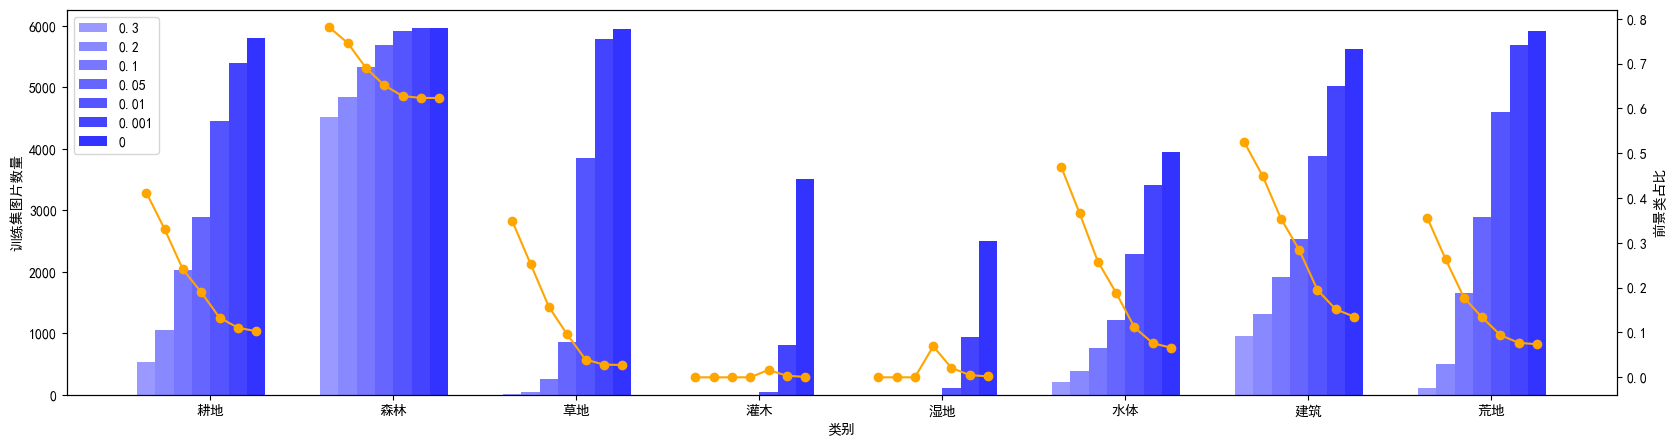

In [82]:
categories = df['类别']
settings = ['0.3', '0.2', '0.1', '0.05', '0.01', '0.001', '0']
image_counts = ['0.3', '0.2', '0.1', '0.05', '0.01', '0.001', '0']
foreground_ratios = ['10.3', '10.2', '10.1', '10.05', '10.01', '10.001', '10']

x = np.arange(len(categories))
len_settings = len(settings)
width = 0.1

import matplotlib
# Specify a font that supports Chinese characters
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # SimHei is a commonly used Chinese font
matplotlib.rcParams['axes.unicode_minus'] = False  # This line is used to ensure that negative signs are displayed correctly

fig, ax1 = plt.subplots(figsize=(20,5))

# Create a color gradient
colors = plt.cm.viridis(np.linspace(0.1, 0.4, len(settings)))
alphas = np.linspace(0.4, 0.8, len(settings))

for i, (setting, image_count) in enumerate(zip(settings, image_counts)):
    ax1.bar(x - len_settings*width/2 + i*width, df[image_count], width, label=setting, color='blue', alpha=alphas[i])

ax1.set_xlabel('类别')
ax1.set_ylabel('训练集图片数量')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()

ax2 = ax1.twinx()

# for i, (setting, foreground_ratio) in enumerate(zip(settings, foreground_ratios)):
#     ax2.plot(x, df[foreground_ratio], marker='o', label=setting)
for i, category in enumerate(categories):
    ax2.plot([i - len_settings*width/2 + j*width for j in range(len(settings))], df[df['类别'] == category][foreground_ratios].values.tolist()[0], marker='o', label=category, color='orange')

ax2.set_ylabel('前景类占比')
# ax2.legend()

# fig.tight_layout()
plt.show()

In [29]:
x = np.arange(len(settings))

category = categories[0]
image_count = image_counts[0]

temp1 = df[df['类别'] == category][image_count]

print(temp1)

print(x)
print(df[df['类别'] == category][image_counts])
print(df[df['类别'] == category][image_counts].values.tolist()[0])

0    541
Name: 0.3, dtype: int64
[0 1 2 3 4 5 6]
   0.3   0.2   0.1  0.05  0.01  0.001     0
0  541  1053  2022  2899  4448   5393  5801
[541, 1053, 2022, 2899, 4448, 5393, 5801]


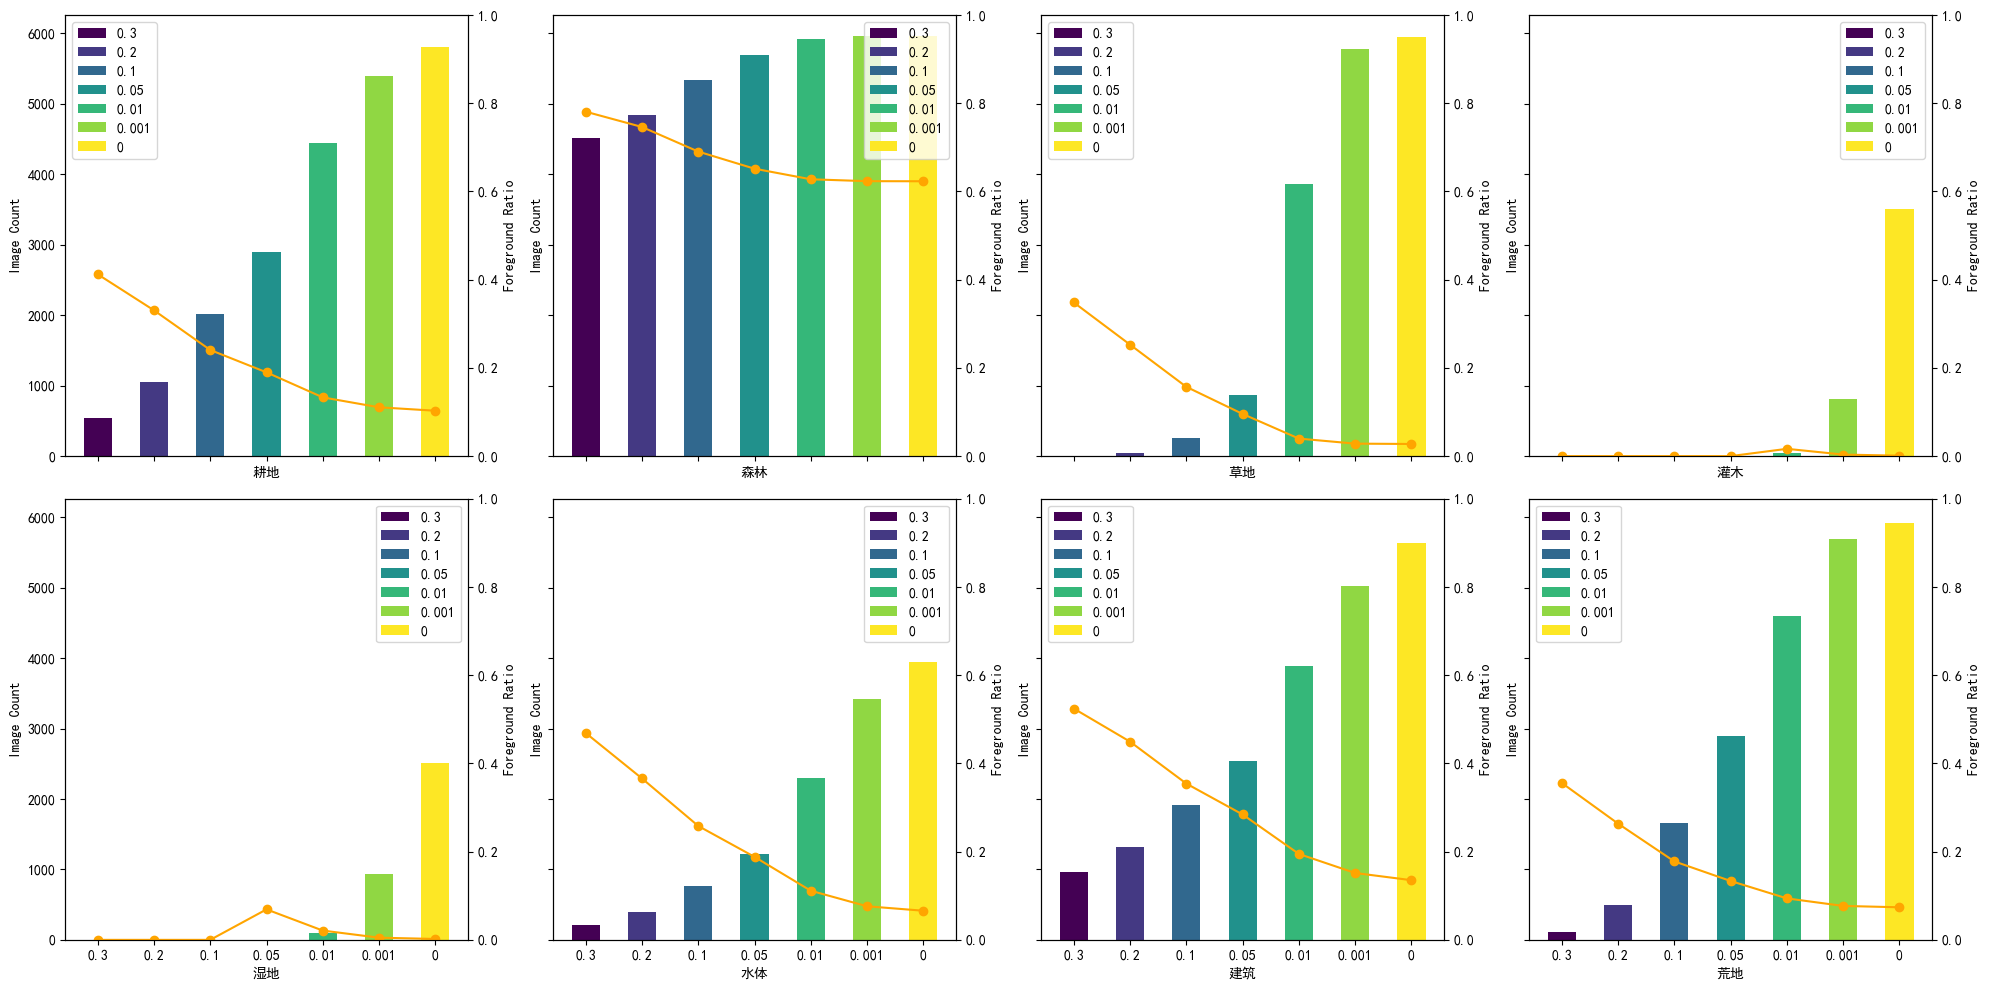

In [50]:
fig, axs = plt.subplots(2, 4, figsize=(5 * 4, 5 * 2), sharex=True, sharey=True)

x = np.arange(len(settings))
width = 0.5

for i, category in enumerate(categories):
    ax1 = axs[i//4, i%4]
    ax2 = ax1.twinx()

    # Create a color gradient
    colors = plt.cm.viridis(np.linspace(0, 1, len(settings)))
    alphas = np.linspace(0, 1, len(settings))
    
    # for setting, image_count in zip(settings, image_counts):
    #     ax1.bar(x, df[df['类别'] == category][image_count], width, label=setting)
    ax1.bar(x, df[df['类别'] == category][image_counts].values.tolist()[0], width, label=settings, color=colors)

    ax1.set_xlabel(category)
    ax1.set_ylabel('Image Count')
    ax1.set_xticks(x)
    ax1.set_xticklabels(settings)
    ax1.legend()

    # for setting, foreground_ratio in zip(settings, foreground_ratios):
    #     ax2.plot(x, df[df['类别'] == category][foreground_ratio], marker='o', label=setting)
    ax2.plot(x, df[df['类别'] == category][foreground_ratios].values.tolist()[0], marker='o', label=setting, color='orange')

    ax2.set_ylabel('Foreground Ratio')
    ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

[[0.71058824 0.71058824 0.71058824 1.        ]
 [0.672203   0.672203   0.672203   1.        ]
 [0.63381776 0.63381776 0.63381776 1.        ]
 [0.59543253 0.59543253 0.59543253 1.        ]
 [0.56024606 0.56024606 0.56024606 1.        ]
 [0.52579777 0.52579777 0.52579777 1.        ]
 [0.49134948 0.49134948 0.49134948 1.        ]
 [0.45690119 0.45690119 0.45690119 1.        ]
 [0.42002307 0.42002307 0.42002307 1.        ]
 [0.38754325 0.38754325 0.38754325 1.        ]
 [0.35506344 0.35506344 0.35506344 1.        ]
 [0.32258362 0.32258362 0.32258362 1.        ]
 [0.27866205 0.27866205 0.27866205 1.        ]
 [0.2343714  0.2343714  0.2343714  1.        ]
 [0.19008074 0.19008074 0.19008074 1.        ]
 [0.14579008 0.14579008 0.14579008 1.        ]
 [0.10925029 0.10925029 0.10925029 1.        ]
 [0.07283353 0.07283353 0.07283353 1.        ]
 [0.03641676 0.03641676 0.03641676 1.        ]
 [0.         0.         0.         1.        ]]


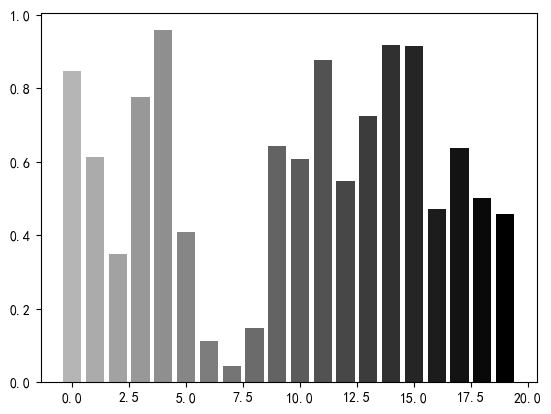

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.arange(20)
y = np.random.rand(20)

# Create a brightness gradient
colors = plt.cm.Greys(np.linspace(0.4, 1, len(y)))
print(colors)
# Create a bar plot with a brightness gradient
plt.bar(x, y, color=colors)

plt.show()